# HR Employee Attrition Analysis using SQL and Python
This project analyzes IBM's HR Employee Attrition dataset to identify key factors driving employee turnover and answer business questions using SQL and Python. The dataset is loaded into aSQLite database, queried using SQL, and the results are analyzed and visualized using Pandas and Matplotlib to generate actionable HR insights.

In [2]:
import pandas as pd
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.shape

(1470, 35)

# The dataset contains 1,470 employee records and 35 columns.

In [4]:
df.columns

Index(['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department',
       'DistanceFromHome', 'Education', 'EducationField', 'EmployeeCount',
       'EmployeeNumber', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate',
       'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction',
       'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked',
       'Over18', 'OverTime', 'PercentSalaryHike', 'PerformanceRating',
       'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel',
       'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance',
       'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion',
       'YearsWithCurrManager'],
      dtype='str')

In [5]:
df['EmployeeCount'].unique()

array([1])

In [6]:
df['Over18'].unique()


<StringArray>
['Y']
Length: 1, dtype: str

In [7]:
df['StandardHours'].unique()

array([80])

# EmployeeCount, Over18, and StandardHours each contain only a single repeated value across all 1,470 rows, confirmed using .unique(). These columns add no analytical value and will be excluded from analysis.

In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

# All 35 columns have 1,470 non-null values, confirming that there are no missing values in the dataset. The dataset contains 26 numeric columns and 9 categorical (text) columns, with no data type issues requiring correction.

In [9]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [10]:
df.duplicated().sum()

np.int64(0)

# The average employee age is about 37 years, ranging from 18 to 60. No duplicate rows were found in the dataset. The EnvironmentSatisfaction, JobInvolvement, and similar rating columns range from 1 to 4, indicating they are surbvey-style scores rather than continuous measurements.

In [11]:
import sqlite3
conn = sqlite3.connect('hr_attrition.db')
df.to_sql('employees', conn, index=False, if_exists='replace')

1470

In [12]:
pd.read_sql("SELECT * FROM EMPLOYEES LIMIT 5", conn)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


## The dataset has been successfully loaded into SQLite database as a table named 'employees'. All subsequent business questions will be answered using SQL queries executed via Python.

## Business Question 1 : Which department has the highest attrition rate?

In [13]:
query1 = """
SELECT Department,
       COUNT(*) AS total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
       ROUND(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END)* 100.0/ COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY Department
ORDER BY attrition_rate DESC
"""

result1 = pd.read_sql(query1, conn)
result1

,Department,total_employees,employees_left,attrition_rate
0,Sales,446,92,20.63
1,Human Resources,63,12,19.05
2,Research & Development,961,133,13.84


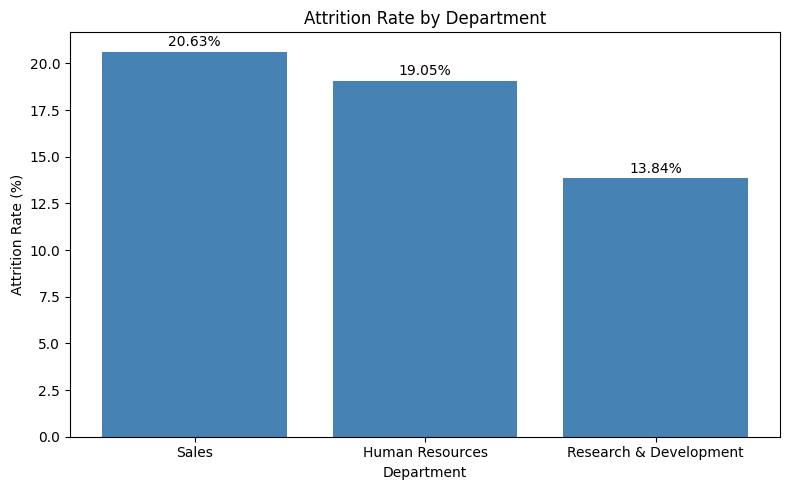

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.bar(result1['Department'], result1['attrition_rate'], color='steelblue')
plt.title('Attrition Rate by Department')
plt.xlabel('Department')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(result1['attrition_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

## Business Insights
- Sales department has the highest attrition rate at 20.63%, meaning roughly 1 in 5 sales employees left the company.
- Human Resources follows closely at 19.05%, indicating retention challenges outside of the core business function.
- Research & Development has the lowest attrition rate at 13.84%, despite being the largest department with 961 employees.
- The company should prioritize investigating and addressing attrition causes specifically in the Sales department, as it has both a high attrition rate and a large headcount of 446 employees.

## Business Question 2 : What is the average monthly income by job role?

In [15]:
query2 = """
SELECT JobRole,
       ROUND(AVG(MonthlyIncome),2) AS avg_monthly_income,
       COUNT (*) AS total_employees
FROM employees
GROUP BY Jobrole
ORDER BY avg_monthly_income DESC
"""

result2 = pd.read_sql(query2, conn)
result2

,JobRole,avg_monthly_income,total_employees
0,Manager,17181.68,102
1,Research Director,16033.55,80
2,Healthcare Representative,7528.76,131
3,Manufacturing Director,7295.14,145
4,Sales Executive,6924.28,326
5,Human Resources,4235.75,52
6,Research Scientist,3239.97,292
7,Laboratory Technician,3237.17,259
8,Sales Representative,2626.00,83


<Figure size 1200x600 with 0 Axes>

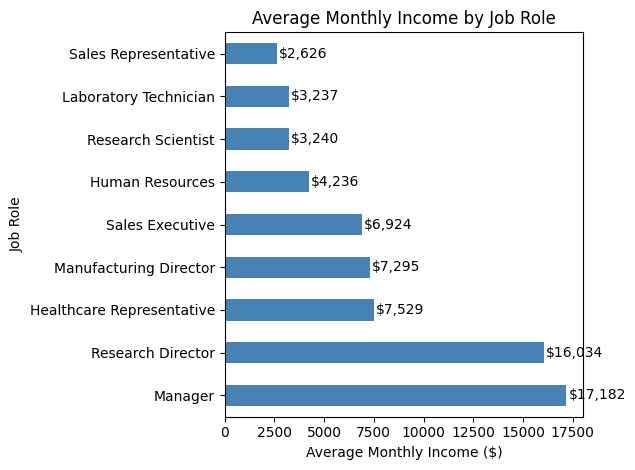

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

ax = result2.plot(kind='barh', x='JobRole', y='avg_monthly_income', legend=False, color='steelblue')

plt.title('Average Monthly Income by Job Role')
plt.xlabel('Average Monthly Income ($)')
plt.ylabel('Job Role')

for i , v in enumerate(result2['avg_monthly_income']):
    plt.text(v + 100, i, f'${v:,.0f}', va = 'center')
plt.tight_layout()
plt.show()

## Business Insights 
- Managers earn the highest average monthly income at $17,182, followed by  Research Directors at $16,034 - both nearly double the next highest role.
- Sales Representatives earn the lowest average monthly income at $2,626, which is less than one-sixth of what managers earn.
- There is a significant compensation gap between senior roles(Manager, Research Director) and entry-level roles (Sales Representative, Laboratory Technician, Research Scientist).
- Notably, Sales Representatives have both the lowest average income and belong to the department with the highest attririon rate (20.63%), suggesting compensation may be a key driver of employee turnover in sales.
- The company should review compensation structures for lower-income roles, particularly Sales Representatives, to improve retention.

## Business Question 3 : How does overtime affect attrition?

In [24]:
query3 = """
SELECT OverTime,
       COUNT(*) AS total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
       ROUND(CAST(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY OverTime
"""
result3 = pd.read_sql(query3, conn)
result3 = result3.sort_values('attrition_rate', ascending=False)
result3

,OverTime,total_employees,employees_left,attrition_rate
1,Yes,416,127,30.53
0,No,1054,110,10.44


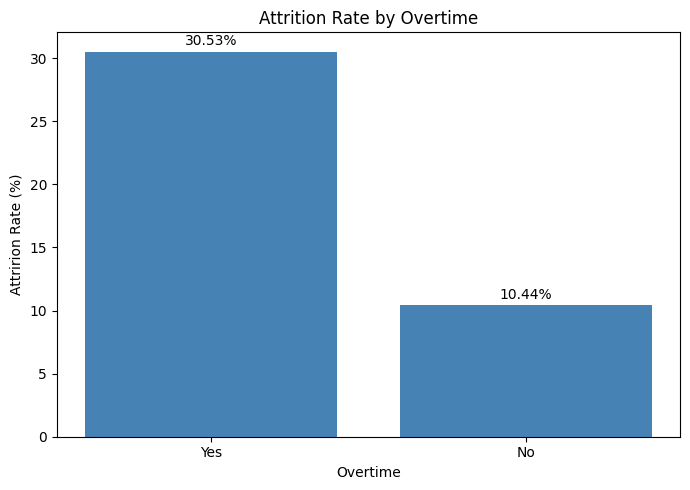

In [26]:
plt.figure(figsize=(7,5))

plt.bar(result3['OverTime'], result3['attrition_rate'], color= 'steelblue')

plt.title('Attrition Rate by Overtime')
plt.xlabel('Overtime')
plt.ylabel('Attririon Rate (%)')

for i , v in enumerate(result3['attrition_rate']):
    plt.text(i, v + 0.5, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

## Business Insights 
- Employees who work overtime have an attririon rate of 30.53%, nearly three times higher than the employees who do not work overtime (10.44%)
- This is the strongest attrition signal found so far in this analysis, suggesting overtime is a major driver of employee turnover.
- Out of 416 employees working overtime, 127 left the company - a significant loss of manpower.
- The company should urgently review its overtime policies,  consider hiring additional staff to reduce workload pressure, and monitor burnout levels among overtime employees.

## Business Question 4 : Which age group has the highest attrition rate?

In [27]:
query4 = """
SELECT 
    CASE 
        WHEN Age < 25 THEN 'Under 25'
        WHEN Age BETWEEN 25 AND 34 THEN '25-34'
        WHEN Age BETWEEN 35 AND 44 THEN '35-44'
        WHEN Age BETWEEN 45 AND 54 THEN '45-54'
        ELSE '55+'
    END AS age_group,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(CAST(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY age_group
"""
result4 = pd.read_sql(query4, conn)
result4 = result4.sort_values('attrition_rate', ascending=False)
result4

,age_group,total_employees,employees_left,attrition_rate
4,Under 25,97,38,39.18
0,25-34,554,112,20.22
3,55+,69,11,15.94
2,45-54,245,25,10.20
1,35-44,505,51,10.10


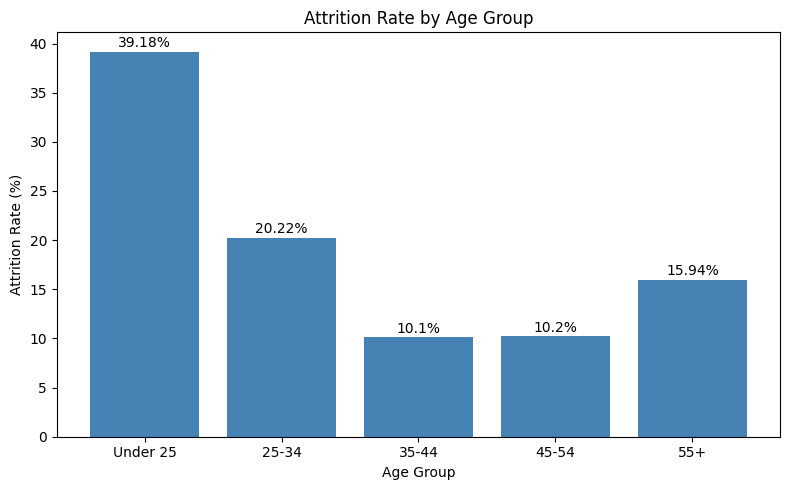

In [29]:
age_order = ['Under 25', '25-34', '35-44', '45-54', '55+']
result4_ordered = result4.set_index('age_group').reindex(age_order).reset_index()

plt.figure(figsize=(8, 5))
plt.bar(result4_ordered['age_group'], result4_ordered['attrition_rate'], color='steelblue')
plt.title('Attrition Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(result4_ordered['attrition_rate']):
    plt.text(i, v + 0.5, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

## Business Insights
- Employees under 25 have the highest attrition rate at 39.18%, 
meaning nearly 2 in 5 young employees leave the company.
- The 25-34 age group follows at 20.22%, suggesting early career 
employees as a whole are the most likely to leave.
- Attrition drops significantly for employees aged 35 and above, 
with the 35-44 group having the lowest rate at 10.10%.
- Younger employees may leave due to limited growth opportunities, 
low engagement, or a desire to explore different career paths.
- The company should focus on retention strategies targeting younger 
employees such as mentorship programs, clear career progression 
paths, and engagement initiatives to reduce early career attrition.

## Business Question 5: What is the attrition rate by gender?

In [30]:
query5 = """
SELECT Gender,
       COUNT(*) AS total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
       ROUND(CAST(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY Gender
"""
result5 = pd.read_sql(query5, conn)
result5 = result5.sort_values('attrition_rate', ascending=False)
result5

,Gender,total_employees,employees_left,attrition_rate
1,Male,882,150,17.01
0,Female,588,87,14.80


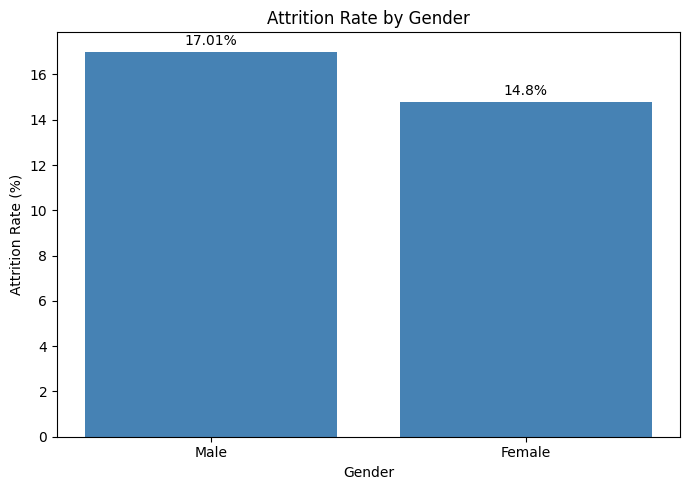

In [31]:
plt.figure(figsize=(7, 5))
plt.bar(result5['Gender'], result5['attrition_rate'], color='steelblue')
plt.title('Attrition Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Attrition Rate (%)')
for i, v in enumerate(result5['attrition_rate']):
    plt.text(i, v + 0.3, f'{v}%', ha='center')
plt.tight_layout()
plt.show()

## Business Insights
- Male employees have a slightly higher attrition rate at 17.01% 
compared to female employees at 14.80%.
- However, the difference of approximately 2.2 percentage points 
is relatively small, suggesting gender is not a major standalone 
driver of attrition in this company.
- Compared to other factors analyzed (overtime at 30.53% vs 10.44%, 
age under 25 at 39.18%), gender shows the weakest attrition signal.
- The company should investigate other contributing factors rather 
than focusing primarily on gender-based retention strategies.

## Business Question 6: Which job role has the highest attrition count?

In [32]:
query6 = """
SELECT JobRole,
       COUNT(*) AS total_employees,
       SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
       ROUND(CAST(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY JobRole
"""
result6 = pd.read_sql(query6, conn)
result6 = result6.sort_values('employees_left', ascending=False)
result6

,JobRole,total_employees,employees_left,attrition_rate
2,Laboratory Technician,259,62,23.94
7,Sales Executive,326,57,17.48
6,Research Scientist,292,47,16.10
8,Sales Representative,83,33,39.76
1,Human Resources,52,12,23.08
4,Manufacturing Director,145,10,6.90
0,Healthcare Representative,131,9,6.87
3,Manager,102,5,4.90
5,Research Director,80,2,2.50


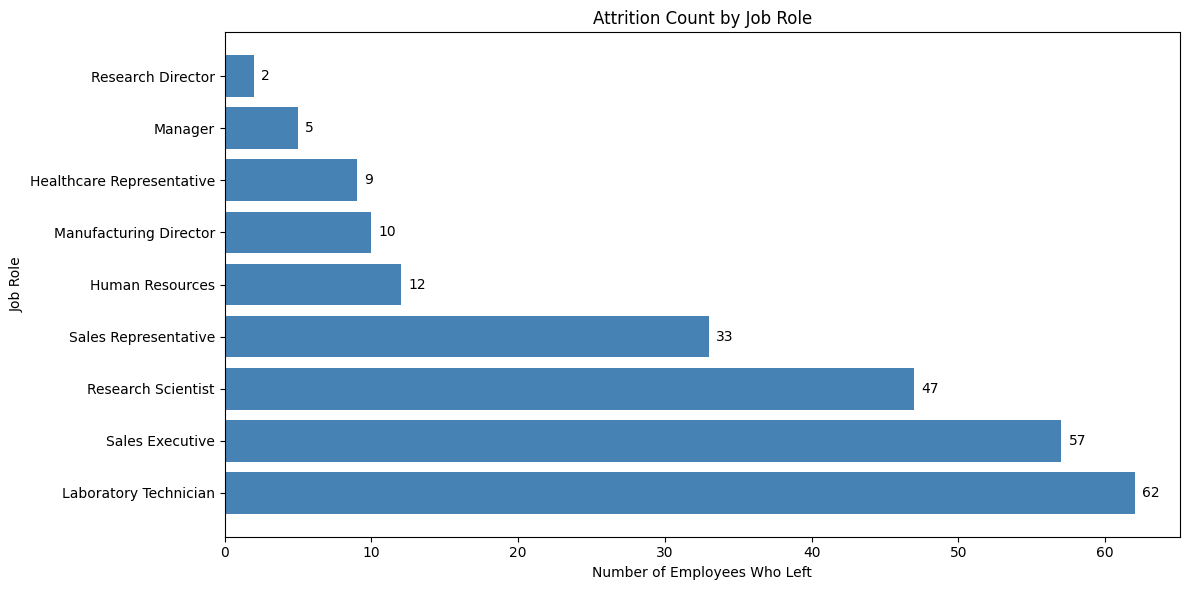

In [33]:
plt.figure(figsize=(12, 6))
plt.barh(result6['JobRole'], result6['employees_left'], color='steelblue')
plt.title('Attrition Count by Job Role')
plt.xlabel('Number of Employees Who Left')
plt.ylabel('Job Role')
for i, v in enumerate(result6['employees_left']):
    plt.text(v + 0.5, i, str(v), va='center')
plt.tight_layout()
plt.show()

## Business Insights
- Laboratory Technicians recorded the highest attrition count 
with 62 employees leaving, followed by Sales Executives (57) 
and Research Scientists (47).
- However, Sales Representatives have the highest attrition rate 
at 39.76%, meaning nearly 2 in 5 Sales Representatives left — 
despite having a smaller total headcount of 83.
- Research Directors and Managers show the lowest attrition counts 
(2 and 5 respectively), suggesting senior leadership roles are 
the most stable in the organization.
- The company should prioritize retention efforts for Laboratory 
Technicians and Sales Representatives as both show significant 
attrition from different perspectives — volume and rate respectively.

## Business Question 7: Does distance from home affect attrition?

In [34]:
query7 = """
SELECT 
    CASE 
        WHEN DistanceFromHome BETWEEN 1 AND 10 THEN 'Near (1-10 km)'
        WHEN DistanceFromHome BETWEEN 11 AND 20 THEN 'Medium (11-20 km)'
        ELSE 'Far (21+ km)'
    END AS distance_group,
    COUNT(*) AS total_employees,
    SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS employees_left,
    ROUND(CAST(SUM(CASE WHEN Attrition = 'Yes' THEN 1 ELSE 0 END) AS REAL) * 100 / COUNT(*), 2) AS attrition_rate
FROM employees
GROUP BY distance_group
"""
result7 = pd.read_sql(query7, conn)
result7 = result7.sort_values('attrition_rate', ascending=False)
result7

,distance_group,total_employees,employees_left,attrition_rate
0,Far (21+ km),204,45,22.06
1,Medium (11-20 km),240,48,20.00
2,Near (1-10 km),1026,144,14.04


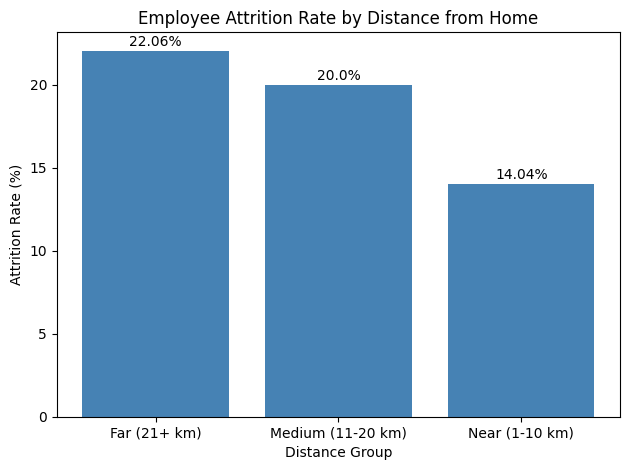

In [37]:
plt.bar(result7['distance_group'],
        result7['attrition_rate'],
        color='steelblue')

plt.title('Employee Attrition Rate by Distance from Home')
plt.xlabel('Distance Group')
plt.ylabel('Attrition Rate (%)')

for i, value in enumerate(result7['attrition_rate']):
    plt.text(i, value + 0.3, f'{value}%', ha='center')

plt.tight_layout()
plt.show()

## Business Insights
- Employees living 21 km or more from the office have the highest attrition rate at 22.06%, indicating that longer commuting distances may contribute to higher employee turnover.
- Employees living 11–20 km away also show a relatively high attrition rate of 20.00%, suggesting that attrition tends to increase as commuting distance increases.
- Employees living 1–10 km from the office have the lowest attrition rate at 14.04%, indicating that employees residing closer to the workplace are more likely to stay with the company.
- The company should consider introducing hybrid work options, flexible work hours, transportation assistance, or relocation support for employees who live farther away to improve retention.

# Final Conclusion

## Project Summary
This project analyzed employee attrition using SQL and Python to identify the key factors affecting employee turnover. The analysis answered seven business questions using SQL queries, data visualization, and business insights.

## Key Findings
- Sales department recorded the highest attrition rate (20.63%), indicating a need for focused retention strategies.
- Employees working overtime experienced an attrition rate of 30.53%, nearly three times higher than employees who did not work overtime.
- Employees under the age of 25 showed the highest attrition rate (39.18%), making young employees the most vulnerable group.
- Attrition increased as employees lived farther from the workplace, with employees living more than 21 km away having the highest attrition rate.
- Laboratory Technicians had the highest number of employees leaving, while Sales Representatives had the highest attrition rate among job roles.
- Male employees had a slightly higher attrition rate than female employees, although gender was not a major driver of employee turnover.
- Managers earned the highest average monthly income, whereas Sales Representatives earned the lowest.

## Recommendations
- Reduce excessive overtime to lower employee burnout.
- Improve retention strategies for Sales employees and younger employees.
- Consider hybrid work, transportation assistance, or relocation support for employees living farther from the workplace.
- Review compensation and career growth opportunities for lower-paid job roles.
- Continue monitoring employee satisfaction and engagement to reduce future attrition.

## Skills Demonstrated
- SQL
- Python
- Pandas
- SQLite
- Matplotlib
- Exploratory Data Analysis (EDA)
- Data Visualization
- Business Insights & Reporting